# TP 2 - Exploration du dataset
## Mastère 2 - Data & Intelligence Artificielle

**Durée** : 30 minutes

### Objectifs
1. Charger le dataset `loan_data.csv`
2. Afficher les 10 premières lignes
3. Identifier les types de variables
4. Compter les valeurs manquantes par colonne
5. Calculer le taux d'approbation global
6. Créer 3 visualisations :
   - Distribution des revenus (histogramme)
   - Taux d'approbation par genre (bar chart)
   - Corrélation entre variables numériques (heatmap)

### Critères de réussite
- ✅ Dataset chargé sans erreur
- ✅ Toutes les visualisations créées
- ✅ Identification correcte des types de variables

## 📦 Imports

In [1]:
# TODO : Importer les librairies nécessaires
# Indices :
# - pandas : pour manipuler les données
# - numpy : pour les calculs numériques
# - matplotlib.pyplot : pour les graphiques
# - seaborn : pour les graphiques avancés

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')

# Force l'affichage inline dans le notebook
%matplotlib inline

# Configuration pour de beaux graphiques
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

---
## 📊 ÉTAPE 1 : Chargement des données

In [2]:
# TODO : Charger le dataset 'loan_data.csv' avec pandas
# Indice : Utilisez pd.read_csv()

df = pd.read_csv('loan_data.csv')

In [3]:
# TODO : Afficher les dimensions du dataset (nombre de lignes et colonnes)
# Indice : Utilisez l'attribut .shape

print(f"\nDimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")


Dimensions : 614 lignes × 13 colonnes


In [4]:
# TODO : Afficher les 10 premières lignes
# Indice : Utilisez .head(10)

print("\n10 premières lignes :")
df.head(10)


10 premières lignes :


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


---
## 🔍 ÉTAPE 2 : Types de variables

In [5]:
# TODO : Afficher les types de données et les valeurs manquantes
# Indice : Utilisez .info()

print("\nInformations sur les colonnes :")
df.info()


Informations sur les colonnes :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
# Afficher les doublons
print(f"\nNombre de doublons : {df.duplicated().sum()}")


Nombre de doublons : 0


In [7]:
# TODO : Identifier les variables numériques et catégorielles
# Indice : 
# - .select_dtypes(include=['int64', 'float64']) pour les numériques
# - .select_dtypes(include=['object']) pour les catégorielles

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nVariables numériques ({len(numerical_cols)}) : {numerical_cols}")
print(f"Variables catégorielles ({len(categorical_cols)}) : {categorical_cols}")


Variables numériques (5) : ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Variables catégorielles (8) : ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


---
## ⚠️ ÉTAPE 3 : Valeurs manquantes

In [8]:
# TODO : Compter les valeurs manquantes par colonne
# Indice : .isnull().sum()

missing_values = df.isnull().sum()

# Calculer le pourcentage
missing_percent = (missing_values / len(df)) * 100

# Créer un DataFrame pour afficher les résultats
missing_df = pd.DataFrame({
    'Colonne': missing_values.index,
    'Nombre de NaN': missing_values.values,
    'Pourcentage': missing_percent.values
})

# Afficher uniquement les colonnes avec des valeurs manquantes
missing_df = missing_df[missing_df['Nombre de NaN'] > 0].sort_values('Nombre de NaN', ascending=False)

if len(missing_df) > 0:
    print("\nColonnes avec valeurs manquantes :")
    print(missing_df.to_string(index=False))
else:
    print("\n✅ Aucune valeur manquante détectée")


Colonnes avec valeurs manquantes :
         Colonne  Nombre de NaN  Pourcentage
  Credit_History             50     8.143322
   Self_Employed             32     5.211726
      LoanAmount             22     3.583062
      Dependents             15     2.442997
Loan_Amount_Term             14     2.280130
          Gender             13     2.117264
         Married              3     0.488599


In [9]:
df_clean = df.copy()

---
## 📈 ÉTAPE 4 : Statistiques descriptives

In [10]:
# TODO : Afficher les statistiques sur les variables numériques
# Indice : Utilisez .describe()

print("\nStatistiques des variables numériques :")
print(df_clean.describe())


Statistiques des variables numériques :
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  592.000000         600.00000   
mean       5403.459283        1621.245798  146.412162         342.00000   
std        6109.041673        2926.248369   85.587325          65.12041   
min         150.000000           0.000000    9.000000          12.00000   
25%        2877.500000           0.000000  100.000000         360.00000   
50%        3812.500000        1188.500000  128.000000         360.00000   
75%        5795.000000        2297.250000  168.000000         360.00000   
max       81000.000000       41667.000000  700.000000         480.00000   

       Credit_History  
count      564.000000  
mean         0.842199  
std          0.364878  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  


In [11]:
# TODO : Calculer le taux d'approbation global
# Note : La variable cible est 'Loan_Status' avec 'Y' = Approved, 'N' = Rejected
# Indice : Compter combien de 'Y' il y a, diviser par le total, multiplier par 100

if 'Loan_Status' in df_clean.columns:
    approval_rate = (df_clean['Loan_Status'] == 'Y').sum() / len(df_clean) * 100
    
    print(f"\n📊 Taux d'approbation global : {approval_rate:.2f}%")
    
    # Distribution de la cible
    print("\nDistribution de Loan_Status :")
    print(df_clean['Loan_Status'].value_counts())


📊 Taux d'approbation global : 68.73%

Distribution de Loan_Status :
Loan_Status
Y    422
N    192
Name: count, dtype: int64


---
## 📊 ÉTAPE 5 : Visualisations

### Instructions
Créez 3 visualisations pour mieux comprendre le dataset :
1. **Distribution des revenus** : Histogramme
2. **Taux d'approbation par genre** : Bar chart
3. **Matrice de corrélation** : Heatmap

Text(0.5, 1.02, 'Exploration du dataset - Loan Approval')

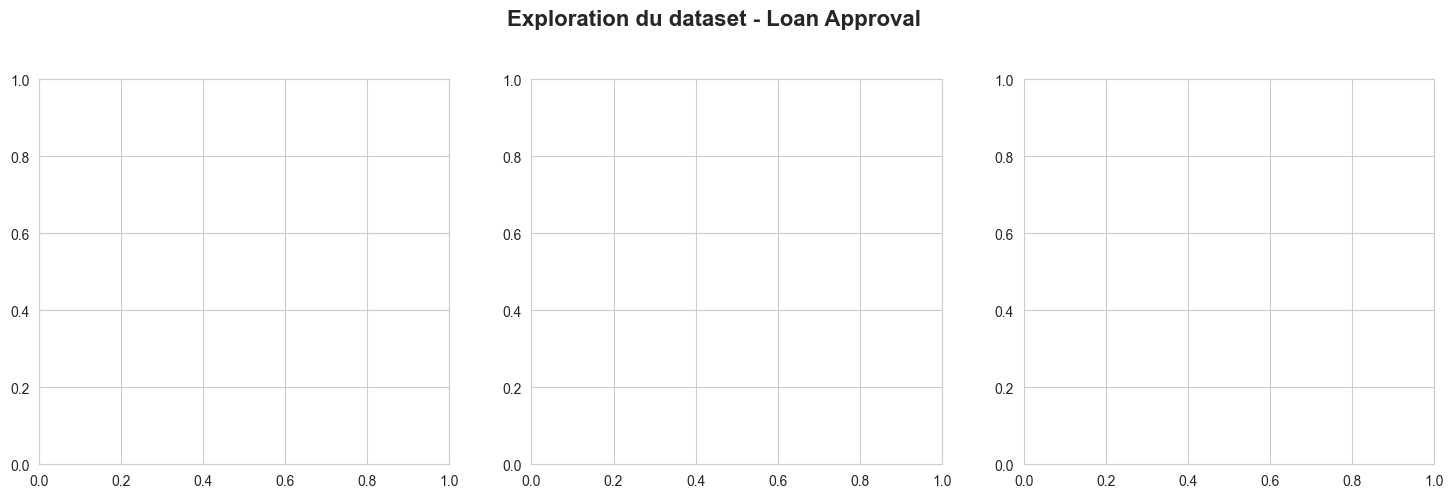

In [12]:
# Créer une figure avec 3 sous-graphiques
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exploration du dataset - Loan Approval', fontsize=16, fontweight='bold', y=1.02)

### 📊 Visualisation 1 : Distribution des revenus

In [13]:
# TODO : Créer un histogramme de ApplicantIncome
# Indice : axes[0].hist(data, bins=30, color='skyblue', edgecolor='black')

# Recréer la figure si les cellules ont été exécutées dans le désordre
if 'axes' not in globals() or len(np.atleast_1d(axes)) < 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Exploration du dataset - Loan Approval', fontsize=16, fontweight='bold', y=1.02)

if 'ApplicantIncome' in df_clean.columns:
    axes[0].hist(df_clean['ApplicantIncome'].dropna(), bins=30, color='skyblue', edgecolor='black')
    
    axes[0].set_xlabel('Revenu du demandeur (€)', fontsize=12)
    axes[0].set_ylabel('Fréquence', fontsize=12)
    axes[0].set_title('Distribution des revenus des demandeurs', fontsize=14, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Bonus : Ajouter une ligne verticale pour la moyenne
    # Indice : axes[0].axvline(mean_value, color='red', linestyle='--')
    mean_income = df_clean['ApplicantIncome'].mean()
    axes[0].axvline(mean_income, color='red', linestyle='--', linewidth=2, label=f'Moyenne: {mean_income:.0f}')
    axes[0].legend()
    
print("✅ Visualisation 1 créée")

✅ Visualisation 1 créée


### 📊 Visualisation 2 : Taux d'approbation par genre

In [14]:
# TODO : Créer un bar chart du taux d'approbation par genre
# Indice : 
# 1. Grouper par Gender avec .groupby('Gender')
# 2. Calculer le taux d'approbation (proportion de 'Y')
# 3. Créer le bar chart avec axes[1].bar()

# Recréer la figure si les cellules ont été exécutées dans le désordre
if 'axes' not in globals() or len(np.atleast_1d(axes)) < 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Exploration du dataset - Loan Approval', fontsize=16, fontweight='bold', y=1.02)

if 'Gender' in df_clean.columns and 'Loan_Status' in df_clean.columns:
    approval_by_gender = df_clean.groupby('Gender')['Loan_Status'].apply(lambda x: (x == 'Y').sum() / len(x) * 100)
    
    axes[1].bar(approval_by_gender.index, approval_by_gender.values, color='lightcoral', edgecolor='black')
    axes[1].set_xlabel('Genre', fontsize=12)
    axes[1].set_ylabel('Taux d\'approbation (%)', fontsize=12)
    axes[1].set_title('Taux d\'approbation par genre', fontsize=14, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    
    # Ajouter les valeurs sur les barres
    for i, v in enumerate(approval_by_gender.values):
        axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

print("✅ Visualisation 2 créée")

✅ Visualisation 2 créée


### 📊 Visualisation 3 : Matrice de corrélation

In [15]:
# TODO : Créer une heatmap des corrélations entre variables numériques
# Indice :
# 1. Sélectionner uniquement les colonnes numériques
# 2. Calculer la matrice de corrélation avec .corr()
# 3. Utiliser sns.heatmap()

# Recréer la figure si les cellules ont été exécutées dans le désordre
if 'axes' not in globals() or len(np.atleast_1d(axes)) < 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Exploration du dataset - Loan Approval', fontsize=16, fontweight='bold', y=1.02)

# Sélectionner uniquement les colonnes numériques
numerical_df = df_clean.select_dtypes(include=['int64', 'float64'])

if len(numerical_df.columns) > 0:
    corr_matrix = numerical_df.corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
                square=True, ax=axes[2], cbar_kws={'label': 'Corrélation'})
    
    axes[2].set_title('Corrélation entre variables numériques', fontsize=14, fontweight='bold')

print("✅ Visualisation 3 créée")

fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig('exploration_visualizations.png', dpi=300, bbox_inches='tight')
print("\n✅ Graphiques sauvegardés dans 'exploration_visualizations.png'")
plt.show()

✅ Visualisation 3 créée

✅ Graphiques sauvegardés dans 'exploration_visualizations.png'


![Visualisations du dataset Loan Approval](exploration_visualizations.png)

*Figure récapitulative enregistrée dans le fichier `exploration_visualizations.png`.*

- La distribution des revenus est **asymétrique vers la droite** : la majorité des demandeurs ont des revenus modérés, avec quelques valeurs très élevées qui tirent la moyenne vers le haut.
- Le taux d'approbation est **légèrement plus élevé** chez les hommes que chez les femmes, mais l'écart reste faible. Le genre ne semble donc pas être le facteur le plus discriminant dans ce dataset.
- La corrélation la plus visible concerne **`ApplicantIncome` et `LoanAmount`** avec une relation **positive** modérée. Les autres variables numériques présentent des corrélations faibles, ce qui suggère des relations linéaires limitées.

---
## BONUS : Analyses complémentaires (optionnel)

Si vous avez terminé en avance, explorez d'autres relations dans les données !


Contingency Table (Éducation vs Approbation) :
Loan_Status     N    Y  All
Education                  
Graduate      140  340  480
Not Graduate   52   82  134
All           192  422  614

Taux d'approbation par niveau d'éducation :
Education
Graduate        70.833333
Not Graduate    61.194030
Name: Loan_Status, dtype: float64


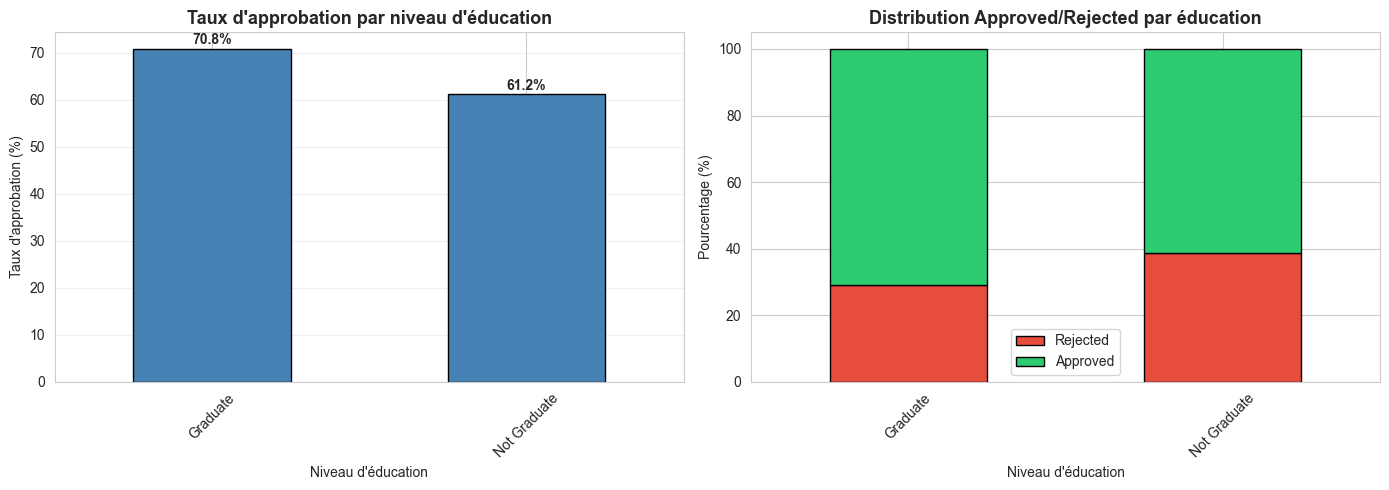

In [16]:
# TODO (Bonus) : Analyser la relation entre l'éducation et l'approbation

if 'Education' in df_clean.columns and 'Loan_Status' in df_clean.columns:
    # Créer un croisement Education vs Loan_Status
    education_approval = pd.crosstab(df_clean['Education'], df_clean['Loan_Status'], margins=True)
    print("\nContingency Table (Éducation vs Approbation) :")
    print(education_approval)
    
    # Calculer le taux d'approbation par niveau d'éducation
    approval_by_education = df_clean.groupby('Education')['Loan_Status'].apply(
        lambda x: (x == 'Y').sum() / len(x) * 100
    )
    
    print("\nTaux d'approbation par niveau d'éducation :")
    print(approval_by_education)
    
    # Visualiser
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart
    approval_by_education.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title('Taux d\'approbation par niveau d\'éducation', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Niveau d\'éducation')
    axes[0].set_ylabel('Taux d\'approbation (%)')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', alpha=0.3)
    
    # Ajouter les valeurs
    for i, v in enumerate(approval_by_education.values):
        axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
    
    # Stacked bar chart
    education_status = pd.crosstab(df_clean['Education'], df_clean['Loan_Status'], normalize='index') * 100
    education_status.plot(kind='bar', stacked=True, ax=axes[1], color=['#e74c3c', '#2ecc71'], edgecolor='black')
    axes[1].set_title('Distribution Approved/Rejected par éducation', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Niveau d\'éducation')
    axes[1].set_ylabel('Pourcentage (%)')
    axes[1].legend(['Rejected', 'Approved'], loc='best')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

**Commentaire :** Les demandeurs diplômés présentent un taux d'approbation plus élevé que les non-diplômés, ce qui suggère que le niveau d'éducation peut être associé à une meilleure probabilité d'acceptation.


Contingency Table (Statut Marital vs Approbation) :
Loan_Status    N    Y  All
Married                   
No            79  134  213
Yes          113  285  398
All          192  419  611

Taux d'approbation par statut marital :
Married
No     62.910798
Yes    71.608040
Name: Loan_Status, dtype: float64


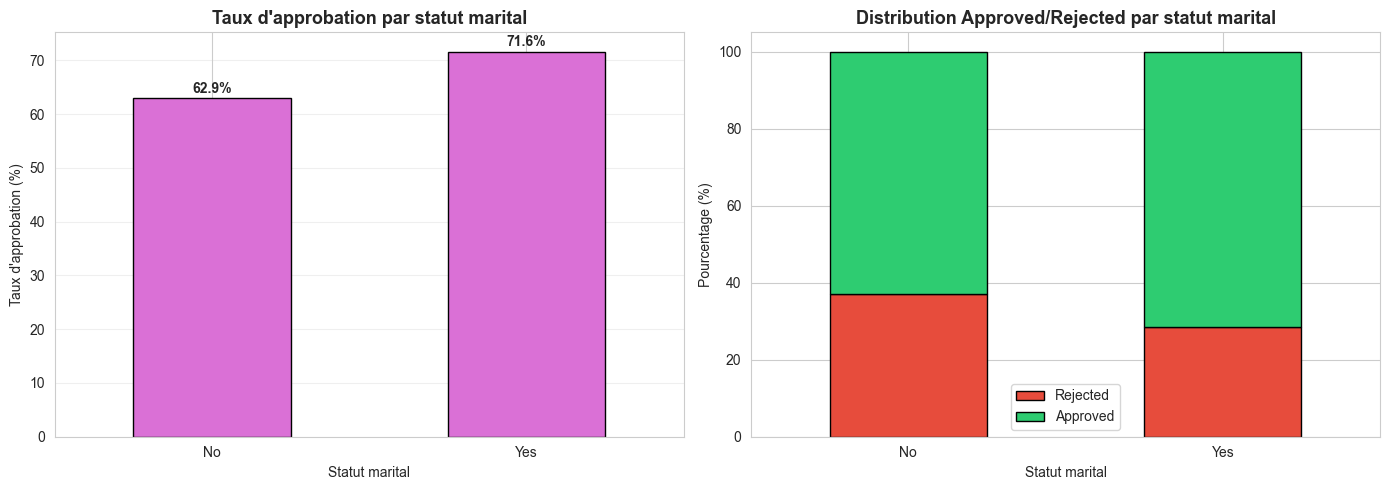

In [17]:
# TODO (Bonus) : Analyser la relation entre le statut marital et l'approbation

if 'Married' in df_clean.columns and 'Loan_Status' in df_clean.columns:
    # Créer un croisement Married vs Loan_Status
    marriage_approval = pd.crosstab(df_clean['Married'], df_clean['Loan_Status'], margins=True)
    print("\nContingency Table (Statut Marital vs Approbation) :")
    print(marriage_approval)
    
    # Calculer le taux d'approbation par statut marital
    approval_by_marriage = df_clean.groupby('Married')['Loan_Status'].apply(
        lambda x: (x == 'Y').sum() / len(x) * 100
    )
    
    print("\nTaux d'approbation par statut marital :")
    print(approval_by_marriage)
    
    # Visualiser
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart
    approval_by_marriage.plot(kind='bar', ax=axes[0], color='orchid', edgecolor='black')
    axes[0].set_title('Taux d\'approbation par statut marital', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Statut marital')
    axes[0].set_ylabel('Taux d\'approbation (%)')
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].grid(axis='y', alpha=0.3)
    
    # Ajouter les valeurs
    for i, v in enumerate(approval_by_marriage.values):
        axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
    
    # Stacked bar chart
    marriage_status = pd.crosstab(df_clean['Married'], df_clean['Loan_Status'], normalize='index') * 100
    marriage_status.plot(kind='bar', stacked=True, ax=axes[1], color=['#e74c3c', '#2ecc71'], edgecolor='black')
    axes[1].set_title('Distribution Approved/Rejected par statut marital', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Statut marital')
    axes[1].set_ylabel('Pourcentage (%)')
    axes[1].legend(['Rejected', 'Approved'], loc='best')
    axes[1].tick_params(axis='x', rotation=0)
    
    plt.tight_layout()
    plt.show()

**Commentaire :** Les personnes mariées semblent avoir un taux d'approbation supérieur aux personnes non mariées, ce qui peut refléter un profil perçu comme plus stable par l'organisme prêteur.


Statistiques du montant du prêt par statut d'approbation :
             count        mean        std   min    25%    50%    75%    max
Loan_Status                                                                
N            181.0  151.220994  85.862783   9.0  100.0  129.0  176.0  570.0
Y            411.0  144.294404  85.484607  17.0  100.0  126.0  161.0  700.0


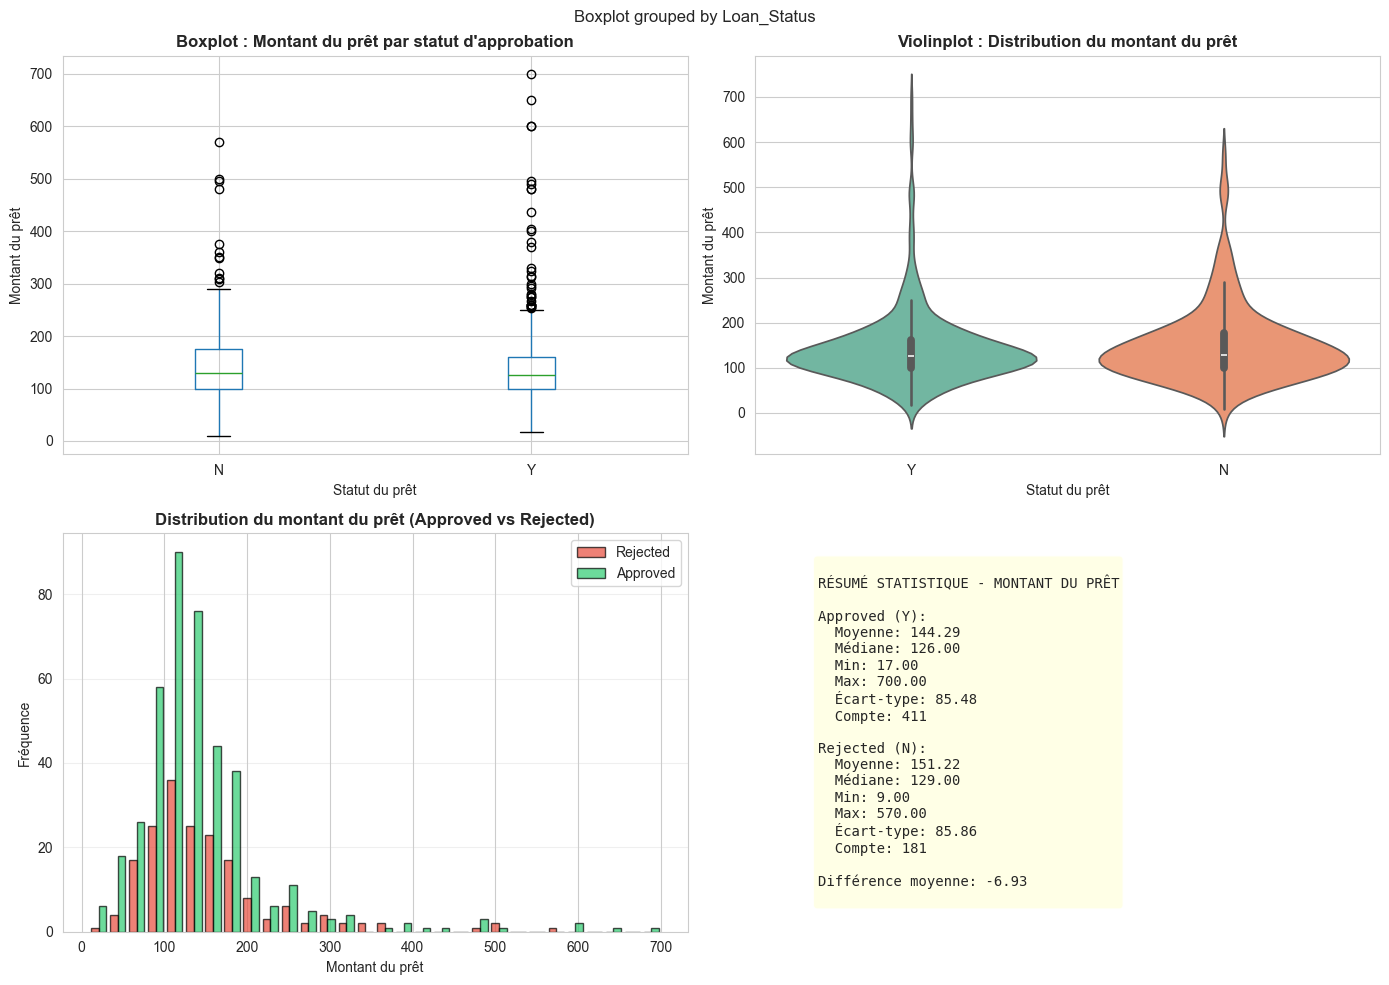

In [18]:
# TODO (Bonus) : Créer un boxplot du montant du prêt par statut d'approbation

if 'LoanAmount' in df_clean.columns and 'Loan_Status' in df_clean.columns:
    # Statistiques descriptives
    loan_stats = df_clean.groupby('Loan_Status')['LoanAmount'].describe()
    print("\nStatistiques du montant du prêt par statut d'approbation :")
    print(loan_stats)
    
    # Créer les visualisations
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Boxplot
    df_clean.boxplot(column='LoanAmount', by='Loan_Status', ax=axes[0, 0])
    axes[0, 0].set_title('Boxplot : Montant du prêt par statut d\'approbation', fontweight='bold')
    axes[0, 0].set_xlabel('Statut du prêt')
    axes[0, 0].set_ylabel('Montant du prêt')
    
    # Violinplot (distribution plus détaillée)
    sns.violinplot(data=df_clean, x='Loan_Status', y='LoanAmount', ax=axes[0, 1], palette='Set2')
    axes[0, 1].set_title('Violinplot : Distribution du montant du prêt', fontweight='bold')
    axes[0, 1].set_xlabel('Statut du prêt')
    axes[0, 1].set_ylabel('Montant du prêt')
    
    # Histogramme superposé
    approved = df_clean[df_clean['Loan_Status'] == 'Y']['LoanAmount'].dropna()
    rejected = df_clean[df_clean['Loan_Status'] == 'N']['LoanAmount'].dropna()
    
    axes[1, 0].hist([rejected, approved], label=['Rejected', 'Approved'], bins=30, 
                    color=['#e74c3c', '#2ecc71'], alpha=0.7, edgecolor='black')
    axes[1, 0].set_title('Distribution du montant du prêt (Approved vs Rejected)', fontweight='bold')
    axes[1, 0].set_xlabel('Montant du prêt')
    axes[1, 0].set_ylabel('Fréquence')
    axes[1, 0].legend()
    axes[1, 0].grid(axis='y', alpha=0.3)
    
    # Résumé statistique
    summary_text = f"""
RÉSUMÉ STATISTIQUE - MONTANT DU PRÊT

Approved (Y):
  Moyenne: {approved.mean():.2f}
  Médiane: {approved.median():.2f}
  Min: {approved.min():.2f}
  Max: {approved.max():.2f}
  Écart-type: {approved.std():.2f}
  Compte: {len(approved)}

Rejected (N):
  Moyenne: {rejected.mean():.2f}
  Médiane: {rejected.median():.2f}
  Min: {rejected.min():.2f}
  Max: {rejected.max():.2f}
  Écart-type: {rejected.std():.2f}
  Compte: {len(rejected)}

Différence moyenne: {approved.mean() - rejected.mean():.2f}
"""
    axes[1, 1].text(0.1, 0.5, summary_text, fontsize=10, family='monospace',
                   verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

**Commentaire :** Le montant du prêt varie dans les deux groupes, mais la médiane est très proche entre prêts approuvés et refusés. Cela suggère que le montant seul n'explique pas complètement la décision d'approbation.

---
## 🎯 Questions de réflexion

Prenez quelques minutes pour réfléchir aux questions suivantes :

1. **Valeurs manquantes** : Quelles colonnes ont le plus de valeurs manquantes ? Pourquoi selon vous ?

2. **Équilibre des classes** : Le taux d'approbation global vous semble-t-il équilibré ? Qu'est-ce que cela implique pour l'entraînement du modèle ?

3. **Biais potentiels** : Y a-t-il une différence de taux d'approbation entre hommes et femmes ? Que pensez-vous de cette différence ?

4. **Corrélations** : Quelles variables numériques sont le plus corrélées ? Comment pourrait-on utiliser cette information ?

5. **Visualisations supplémentaires** : Quelles autres visualisations seriez-vous intéressés à créer pour mieux comprendre les données ?

**Notez vos réponses ci-dessous :**

**Vos réponses :**

1. Les colonnes avec le plus de valeurs manquantes sont `Credit_History` (50), `Self_Employed` (32) et `LoanAmount` (22). Cela peut venir d'un remplissage incomplet des dossiers de demande, de données administratives absentes ou de champs plus difficiles à renseigner correctement.

2. Le taux d'approbation global est de **68,73 %**, donc les classes ne sont pas parfaitement équilibrées. Le dataset est modérément orienté vers la classe `Y`. Pour l'entraînement d'un modèle, cela peut favoriser les prédictions d'approbation et il faudra donc surveiller les métriques comme le recall, la precision, la matrice de confusion ou éventuellement utiliser des techniques de rééquilibrage si nécessaire.

3. Oui, il existe une petite différence entre hommes et femmes : **69,12 %** d'approbation pour les hommes contre **67,00 %** pour les femmes. L'écart reste faible, donc il faut rester prudent. Cela ne prouve pas une causalité, mais cela peut signaler un biais potentiel dans les données ou dans les conditions d'octroi.

4. La corrélation la plus marquée est entre `ApplicantIncome` et `LoanAmount` avec **0,57**. Cela suggère qu'un revenu plus élevé est associé à un montant de prêt plus important. Cette information peut être utile pour la sélection de variables, l'interprétation du modèle et la compréhension des mécanismes d'octroi.

5. D'autres visualisations intéressantes seraient : un boxplot de `LoanAmount` selon `Loan_Status`, un graphique du taux d'approbation selon `Education`, `Married` ou `Property_Area`, un scatter plot `ApplicantIncome` vs `LoanAmount` coloré par `Loan_Status`, ou encore une visualisation spécifique de `Credit_History` par statut d'approbation.

---
## Nettoyage et Feature Engineering

### Objectifs

1. Traitement des valeurs manquantes
- Variables catégorielles : imputation par la modalité la plus fréquente (mode)
- Variables numériques : imputation par la médiane

La copie `df_clean` sera utilisée pour la suite des analyses.

2. Détecter et traiter les outliers sur `ApplicantIncome`
3. Créer les features suivantes :
   - `TotalIncome`
   - `LoanAmountToIncome`
   - `EMI`
   - `Log_LoanAmount`
4. Encoder les variables catégorielles
5. Sauvegarder le dataset nettoyé (`loan_data_clean.csv`)

In [19]:
# Colonnes cibles (adaptées au dataset loan_data.csv)
categorical_to_fill = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
numerical_to_fill = ['LoanAmount', 'Loan_Amount_Term']

# Imputation des variables catégorielles avec le mode
for col in categorical_to_fill:
    if col in df_clean.columns:
        mode_value = df_clean[col].mode(dropna=True)
        if len(mode_value) > 0:
            df_clean[col] = df_clean[col].fillna(mode_value.iloc[0])

# Imputation des variables numériques avec la médiane
for col in numerical_to_fill:
    if col in df_clean.columns:
        median_value = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_value)

# Vérification après traitement
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

print("✅ Valeurs manquantes traitées dans df_clean")
print(f"NaN restants (total): {df_clean.isnull().sum().sum()}")

if len(remaining_missing) > 0:
    print("\nColonnes avec NaN restants :")
    print(remaining_missing.to_string())
else:
    print("\n🎉 Plus aucune valeur manquante dans df_clean")

✅ Valeurs manquantes traitées dans df_clean
NaN restants (total): 0

🎉 Plus aucune valeur manquante dans df_clean


In [20]:
# Détecter et traiter les outliers de ApplicantIncome (méthode IQR + capping)
if 'ApplicantIncome' in df_clean.columns:
    q1 = df_clean['ApplicantIncome'].quantile(0.25)
    q3 = df_clean['ApplicantIncome'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers_before = ((df_clean['ApplicantIncome'] < lower_bound) | (df_clean['ApplicantIncome'] > upper_bound)).sum()
    df_clean['ApplicantIncome'] = df_clean['ApplicantIncome'].clip(lower=lower_bound, upper=upper_bound)
    outliers_after = ((df_clean['ApplicantIncome'] < lower_bound) | (df_clean['ApplicantIncome'] > upper_bound)).sum()
    
    print(f"Outliers ApplicantIncome avant traitement : {outliers_before}")
    print(f"Outliers ApplicantIncome après traitement : {outliers_after}")

# Feature Engineering
if {'ApplicantIncome', 'CoapplicantIncome'}.issubset(df_clean.columns):
    df_clean['TotalIncome'] = df_clean['ApplicantIncome'] + df_clean['CoapplicantIncome']
else:
    df_clean['TotalIncome'] = df_clean.get('ApplicantIncome', 0)

epsilon = 1e-6
if {'LoanAmount', 'TotalIncome'}.issubset(df_clean.columns):
    df_clean['LoanAmountToIncome'] = df_clean['LoanAmount'] / (df_clean['TotalIncome'] + epsilon)

if {'LoanAmount', 'Loan_Amount_Term'}.issubset(df_clean.columns):
    # Approximation d'une mensualité simple (sans taux d'intérêt)
    df_clean['EMI'] = df_clean['LoanAmount'] / df_clean['Loan_Amount_Term'].replace(0, np.nan)
    df_clean['EMI'] = df_clean['EMI'].fillna(0)

if 'LoanAmount' in df_clean.columns:
    df_clean['Log_LoanAmount'] = np.log1p(df_clean['LoanAmount'])

# Encodage des variables catégorielles (label encoding simple)
categorical_cols_clean = df_clean.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols_clean:
    df_clean[col] = pd.factorize(df_clean[col])[0]

# Sauvegarde du dataset nettoyé
df_clean.to_csv('loan_data_clean.csv', index=False)

print("✅ Dataset sauvegardé : loan_data_clean.csv")
print("\nNouvelles colonnes créées :")
for feature in ['TotalIncome', 'LoanAmountToIncome', 'EMI', 'Log_LoanAmount']:
    if feature in df_clean.columns:
        print(f"- {feature}")

print("\nAperçu du dataset final :")
df_clean.head()

Outliers ApplicantIncome avant traitement : 50
Outliers ApplicantIncome après traitement : 0
✅ Dataset sauvegardé : loan_data_clean.csv

Nouvelles colonnes créées :
- TotalIncome
- LoanAmountToIncome
- EMI
- Log_LoanAmount

Aperçu du dataset final :


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanAmountToIncome,EMI,Log_LoanAmount
0,0,0,0,0,0,0,5849.0,0.0,128.0,360.0,1.0,0,0,5849.0,0.021884,0.355556,4.859812
1,1,0,1,1,0,0,4583.0,1508.0,128.0,360.0,1.0,1,1,6091.0,0.021015,0.355556,4.859812
2,2,0,1,0,0,1,3000.0,0.0,66.0,360.0,1.0,0,0,3000.0,0.022000,0.183333,4.204693
3,3,0,1,0,1,0,2583.0,2358.0,120.0,360.0,1.0,0,0,4941.0,0.024287,0.333333,4.795791
4,4,0,0,0,0,0,6000.0,0.0,141.0,360.0,1.0,0,0,6000.0,0.023500,0.391667,4.955827
